In [ ]:
!pip install qiskit qiskit-algorithms qiskit_aer pylatexenc qiskit-nature pyscf qiskit-nature[pyscf]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a4ec6b6c797da8466e193da572f36ff2be520e4feae1893192f2b4555361a5db
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper,ParityMapper,TaperedQubitMapper
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import SPSA,COBYLA,L_BFGS_B,SLSQP
from qiskit_nature.second_q.circuit.library import UCCSD,HartreeFock,UCC
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_algorithms import NumPyMinimumEigensolver

vqe in molecules using parity mapping

In [ ]:
estimator=Estimator()

In [ ]:
#H2

In [ ]:
driver=PySCFDriver(atom='H 0 0 0 ;H 0 0 0.735')
problem=driver.run()
hamiltonian=problem.hamiltonian
second_quantized_hamiltonian=hamiltonian.second_q_op()
mapper=ParityMapper(num_particles=problem.num_particles)
hamiltonian=mapper.map(second_quantized_hamiltonian)
print(hamiltonian)

SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-1.05237325+0.j,  0.39793742+0.j, -0.39793742+0.j, -0.0112801 +0.j,
  0.1809312 +0.j])


In [ ]:
values_uccsd=[]
counts_uccsd=[]

def callback_uccsd(eval_count,parameters,mean,std):
    counts_uccsd.append(eval_count)
    values_uccsd.append(mean)

In [ ]:
initial_state=HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper
)


In [ ]:
ansatz=UCCSD(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state

)

In [ ]:
vqe_uccsd=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback_uccsd,
    initial_point=None
            )


In [ ]:
result_vqe_uccsd=vqe_uccsd.compute_minimum_eigenvalue(hamiltonian).eigenvalue.real


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [ ]:
print(result_vqe_uccsd)

-1.8572750302023666


In [ ]:
solver=NumPyMinimumEigensolver()
result_exact=solver.compute_minimum_eigenvalue(hamiltonian).eigenvalue.real
print(result_exact)

-1.857275030202381


/tmp/ipykernel_874/2471013000.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


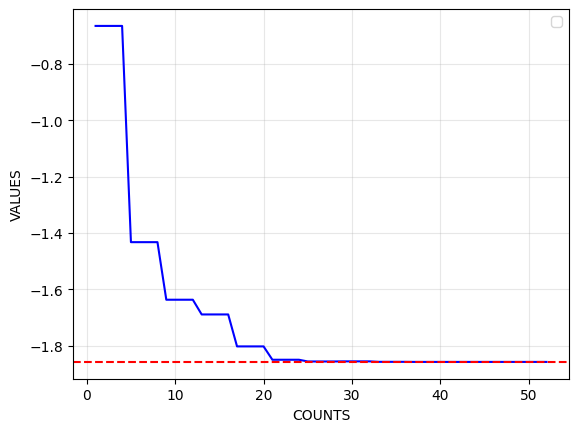

In [ ]:
plt.plot(counts_uccsd,values_uccsd,color='blue',linestyle='-')
plt.axhline(result_exact,color='red',linestyle='--')
plt.xlabel('COUNTS')
plt.ylabel('VALUES')
plt.grid(True, alpha =0.3)
plt.legend()
plt.show()

In [ ]:
#LiH

In [ ]:
driver=PySCFDriver(atom='Li 0 0 0 ; H 0 0 1.595', basis='sto3g')
problem=driver.run()

In [ ]:
transform=ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
reduced_problem=transform.transform(problem)
reduced_problem_hamiltonian=reduced_problem.hamiltonian

In [ ]:
nuclear_repulsion=reduced_problem_hamiltonian.constants.get('nuclear_repulsion_energy',0.0)
energy_shift=reduced_problem_hamiltonian.constants.get('ActiveSpaceTransformer',0.0)
constant_shift=nuclear_repulsion+energy_shift
print(nuclear_repulsion)
print(energy_shift)
print(constant_shift)

0.995317638094044
-7.798291188105946
-6.8029735500119015


In [ ]:
mapper=ParityMapper(num_particles=reduced_problem.num_particles)
qubit_hamiltonian=mapper.map(reduced_problem_hamiltonian.second_q_op())
print(qubit_hamiltonian)

SparsePauliOp(['IIII', 'IIIZ', 'IIZZ', 'IIZI', 'IZII', 'IZIZ', 'ZXII', 'ZXIZ', 'IXII', 'IXIZ', 'ZZII', 'ZZIZ', 'ZIII', 'ZIIZ', 'IIZX', 'IIIX', 'IZZX', 'IZIX', 'ZXZX', 'IXZX', 'ZXIX', 'IXIX', 'ZZZX', 'ZZIX', 'ZIZX', 'ZIIX', 'XXXX', 'YYXX', 'XXYY', 'YYYY', 'XZXX', 'XIXX', 'XZYY', 'XIYY', 'IZZZ', 'ZXZZ', 'IXZZ', 'ZZZZ', 'ZIZZ', 'XXXZ', 'YYXZ', 'XXXI', 'YYXI', 'XZXZ', 'XIXZ', 'XZXI', 'XIXI', 'IZZI', 'ZXZI', 'IXZI', 'ZZZI', 'ZIZI'],
              coeffs=[-0.46109435+0.j, -0.03338852+0.j, -0.20741564+0.j,  0.21422629+0.j,
  0.03338852+0.j, -0.12191446+0.j,  0.01540652+0.j,  0.01212374+0.j,
  0.01540652+0.j,  0.01212374+0.j, -0.20741564+0.j,  0.05593827+0.j,
 -0.21422629+0.j,  0.06760454+0.j, -0.01540652+0.j,  0.01540652+0.j,
  0.01212374+0.j, -0.01212374+0.j, -0.00325349+0.j, -0.00325349+0.j,
  0.00325349+0.j,  0.00325349+0.j,  0.00185455+0.j, -0.00185455+0.j,
  0.00142823+0.j, -0.00142823+0.j,  0.00586253+0.j, -0.00586253+0.j,
 -0.00586253+0.j,  0.00586253+0.j, -0.00481815+0.j,  0.00481815+

In [ ]:
initial_state=HartreeFock(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper
)
values=[]
counts=[]

def callback(eval_count,parameters,mean,std):
    counts.append(eval_count)
    values.append(mean)

In [ ]:
ansatz=UCCSD(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state

)

In [ ]:
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback,
    initial_point=None
)

In [ ]:
energy_uccsd=vqe.compute_minimum_eigenvalue(qubit_hamiltonian).eigenvalue.real
energy_uccsd_real=energy_uccsd+constant_shift
print(energy_uccsd_real)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-7.863077742453491


In [ ]:
result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_hamiltonian)

In [ ]:
exact_energy = result.eigenvalue.real + constant_shift
print(exact_energy)

-7.863077753982218


In [ ]:
values_uccsd=[raw_energy+constant_shift for raw_energy in values]

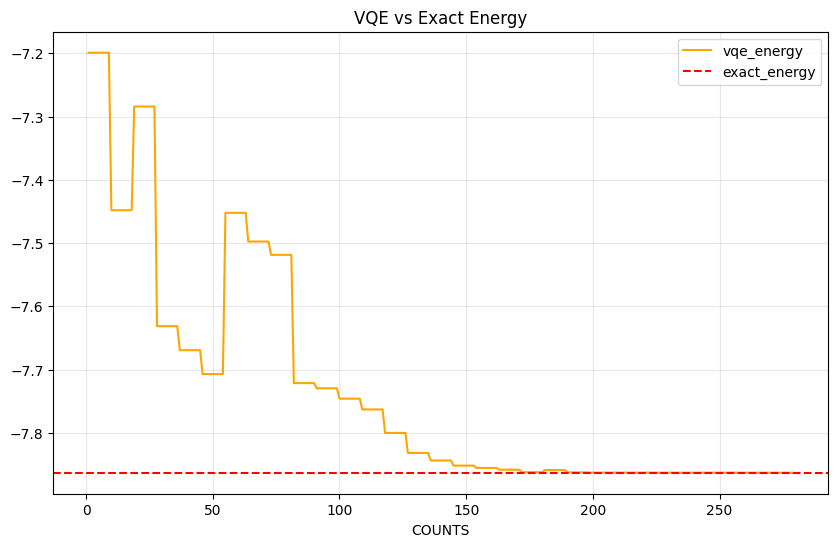

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(counts,values_uccsd,color='orange',linestyle='-',label='vqe_energy')
plt.axhline(exact_energy,color='red',linestyle='--',label='exact_energy')
plt.xlabel('COUNTS')
plt.ylabel='ENERGY'
plt.title('VQE vs Exact Energy')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [ ]:
#BeH2

In [ ]:
driver = PySCFDriver(
    atom='Be 0 0 0; H 0 0 -1.33; H 0 0 1.33',
    basis="sto3g"
)
problem = driver.run()
transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=4)
reduced_problem = transformer.transform(problem)
reduced_problem_hamiltonian=reduced_problem.hamiltonian

nuclear_repulsion_energy=reduced_problem_hamiltonian.constants.get('nuclear_repulsion_energy',0.0)
energy_shift=reduced_problem_hamiltonian.constants.get('ActiveSpaceTransformer',0.0)
constant_shift=nuclear_repulsion_energy+energy_shift
print(nuclear_repulsion_energy)
print(energy_shift)
print(constant_shift)

3.381959618661655
-15.030944571557903
-11.648984952896248


In [ ]:
mapper=ParityMapper(num_particles=reduced_problem.num_particles)
qubit_hamiltonian=mapper.map(reduced_problem_hamiltonian.second_q_op())
print(qubit_hamiltonian)

SparsePauliOp(['IIIIII', 'IIIIIZ', 'IIIIZZ', 'IIIIZI', 'IIIZZI', 'IIIZZZ', 'IIIZII', 'IIIZIZ', 'IIZIII', 'IIZIIZ', 'IZZIII', 'IZZIIZ', 'ZZIIII', 'ZZIIIZ', 'ZIIIII', 'ZIIIIZ', 'IZXIZX', 'IIXIZX', 'IZXIIX', 'IIXIIX', 'ZXXZXX', 'IYYZXX', 'ZXXIYY', 'IYYIYY', 'XXXXXX', 'YXYXXX', 'XXXYXY', 'YXYYXY', 'IIZIZZ', 'IZZIZZ', 'ZZIIZZ', 'ZIIIZZ', 'ZXZZXZ', 'IXIZXZ', 'ZXZIXI', 'IXIIXI', 'XXZXXZ', 'YYIXXZ', 'XXZYYI', 'YYIYYI', 'IIZZZI', 'IZZZZI', 'ZZIZZI', 'ZIIZZI', 'XZIXZI', 'XIIXZI', 'XZIXII', 'XIIXII', 'IIZZII', 'IZZZII', 'ZZIZII', 'ZIIZII', 'IZIIII', 'ZZZIII', 'ZIZIII'],
              coeffs=[-2.84351186+0.j,  0.14881382+0.j,  0.13514105+0.j,  0.15614859+0.j,
 -0.06608242+0.j,  0.16544292+0.j, -0.06608242+0.j,  0.16544292+0.j,
  0.14881382+0.j,  0.0996452 +0.j,  0.13514105+0.j,  0.10298056+0.j,
 -0.06608242+0.j,  0.09231338+0.j, -0.06608242+0.j,  0.09231338+0.j,
  0.0411097 +0.j, -0.0411097 +0.j, -0.0411097 +0.j,  0.0411097 +0.j,
  0.01235982+0.j,  0.01235982+0.j,  0.01235982+0.j,  0.01235982+0.j,

In [ ]:
values=[]
counts=[]

def callback(eval_count,parameters,mean,std):
    counts.append(eval_count)
    values.append(mean)
initial_state=HartreeFock(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper
)

In [ ]:
ansatz=UCCSD(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state

)
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback,
    initial_point=None
)

In [ ]:
energy_uccsd=vqe.compute_minimum_eigenvalue(qubit_hamiltonian).eigenvalue.real
print(energy_uccsd)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-3.9143204891914


In [ ]:
energy_real_uccsd=energy_uccsd+constant_shift
print(energy_real_uccsd)

-15.563305442087648


In [ ]:
result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_hamiltonian)
exact_energy = result.eigenvalue.real + constant_shift
print(exact_energy)

-15.565990709355493


In [ ]:
vqe_energy=[raw_energy+constant_shift for raw_energy in values]

/tmp/ipykernel_874/2685931995.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


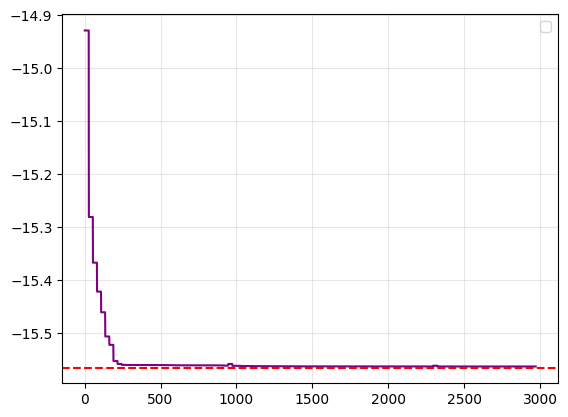

In [ ]:
plt.plot(counts,vqe_energy,color='purple',linestyle='-')
plt.axhline(exact_energy,color='red',linestyle='--')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [ ]:
#H2O


In [ ]:
driver = PySCFDriver(
    atom='O 0 0 0; H 0 0.757 0.586; H 0 -0.757 0.586',
    basis="sto3g"
)
problem = driver.run()

tranformer=ActiveSpaceTransformer(num_electrons=6,num_spatial_orbitals=5)
reduced_problem=tranformer.transform(problem)
reduced_problem_hamiltonian=reduced_problem.hamiltonian



In [ ]:
mapper=ParityMapper(num_particles=reduced_problem.num_particles)
qubit_hamiltonian=mapper.map(reduced_problem_hamiltonian.second_q_op())
print(qubit_hamiltonian)



SparsePauliOp(['IIIIIIII', 'IIIIIIIZ', 'IIIIXXXX', 'IIIIYXXY', 'IIIIIIZZ', 'IIIIZXXZ', 'IIIIIYYI', 'IIIIIZZI', 'IIIIZZII', 'IIIIZIII', 'IIIZIIII', 'XXXXIIII', 'YXXYIIII', 'IIZZIIII', 'ZXXZIIII', 'IYYIIIII', 'IZZIIIII', 'ZZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIZXXI', 'IIIIIYYZ', 'IIIIIZZZ', 'IIIIZZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'XXXXIIIZ', 'YXXYIIIZ', 'IIZZIIIZ', 'ZXXZIIIZ', 'IYYIIIIZ', 'IZZIIIIZ', 'ZZIIIIIZ', 'ZIIIIIIZ', 'IIIIXXYY', 'IIIIYXYX', 'IIIIXZZX', 'IIIIXIZX', 'IIIIYIIY', 'IIIIYZZY', 'IIIIXZIX', 'IIIIXIIX', 'IIZXIIZX', 'IIIXIIZX', 'IIZXIIIX', 'IIIXIIIX', 'ZXXXIIZX', 'IYXYIIZX', 'ZXXXIIIX', 'IYXYIIIX', 'XXXZIIZX', 'YXYIIIZX', 'XXXZIIIX', 'YXYIIIIX', 'XZIIIIZX', 'XIIIIIZX', 'XZIIIIIX', 'XIIIIIIX', 'IIIIXYYX', 'IIIIYYYY', 'IZXXIZXX', 'IIYYIZXX', 'IZXXIIYY', 'IIYYIIYY', 'XXZIIZXX', 'YYIIIZXX', 'XXZIIIYY', 'YYIIIIYY', 'IIIIYYXX', 'IIIIXYXY', 'IIZXZXXX', 'IIIXZXXX', 'IIZXIYXY', 'IIIXIYXY', 'ZXXXZXXX', 'IYXYZXXX', 'ZXXXIYXY', 'IYXYIYXY', 'XXXZZXXX', 'YXYIZXXX', 'XXXZIYXY', 'YXYIIYXY', '

In [ ]:
electronic_energy=reduced_problem_hamiltonian.constants.get('nuclear_repulsion_energy',0.0)
energy_shift=reduced_problem_hamiltonian.constants.get('ActiveSpaceTransformer',0.0)
constant_shift=electronic_energy+energy_shift
print(electronic_energy)
print(energy_shift)
print(constant_shift)

9.193913160623385
-71.37412447423563
-62.18021131361225


In [ ]:
initial_state=HartreeFock(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper
)

ansatz=UCCSD(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state


)

values=[]
counts=[]

def callbacK(eval_count,parameters,mean,std):
    counts.append(eval_count)
    values.append(mean)

In [ ]:
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callbacK,
    initial_point=None
)

In [ ]:
exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(qubit_hamiltonian)
exact_electronic_energy = exact_result.eigenvalue.real+constant_shift
print(exact_electronic_energy)

-74.99667929472005


In [ ]:
vqe_energy=vqe.compute_minimum_eigenvalue(qubit_hamiltonian).eigenvalue.real
print(vqe_energy)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [ ]:
vqe_energy_real=vqe_energy+constant_shift
print(vqe_energy_real)

NameError: name 'vqe_energy' is not defined

In [ ]:
vqe_energies=[raw_energy+constant_shift for raw_energy in values]

/tmp/ipykernel_7004/201793765.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


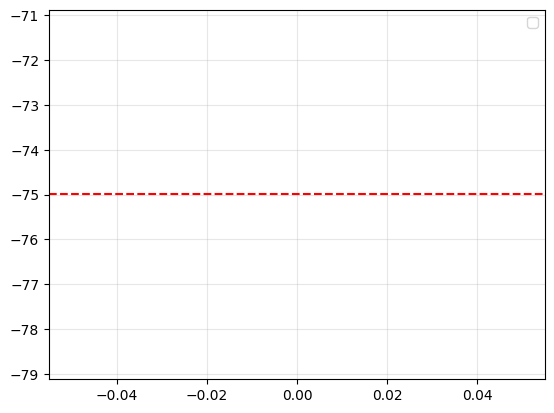

In [ ]:
plt.plot(counts,vqe_energies,color='#76FC00',linestyle='-')
plt.axhline(exact_electronic_energy,color='red',linestyle='--')
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()

In [ ]:
#HF

In [ ]:
driver=PySCFDriver(atom='H 0 0 0 ;F 0 0 0.917', basis='sto3g')
problem=driver.run()
transformer=ActiveSpaceTransformer(num_electrons=8,num_spatial_orbitals=6)
reduced_problem=transformer.transform(problem)
reduced_problem_hamiltonian=reduced_problem.hamiltonian

mapper=ParityMapper(num_particles=reduced_problem.num_particles)
qubit_hamiltonian=mapper.map(reduced_problem_hamiltonian.second_q_op())
print(qubit_hamiltonian)

QiskitNatureError: 'More orbitals requested than available.'

In [ ]:
electronic_energy=reduced_problem_hamiltonian.constants.get('nuclear_repulsion_energy',0.0)
energy_shift=reduced_problem_hamiltonian.constants.get('ActiveSpaceTransformer',0.0)
constant_shift=electronic_energy+energy_shift
print(electronic_energy)
print(energy_shift)
print(constant_shift)

In [ ]:
initial_state=HartreeFock(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper
)

values=[]
counts=[]
def callback(eval_count,parameters,mean,std):
    counts.append(eval_count)
    values.append(mean)

ansatz=UCCSD(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state

)

In [ ]:
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=25),
    callback=callback,
    initial_point=None
)


In [ ]:
vqe_energy=vqe.compute_minimum_eigenvalue(qubit_hamiltonian).eigenvalue.real

In [ ]:
total_vqe_energy=vqe_energy+constant_shift
print(total_vqe_energy)
exact_solver=NumPyMinimumEigensolver()
exact_result=exact_solver.compute_minimum_eigenvalue(hamiltonian)
exact_electronic_energy=exact_result.eigenvalue.real+constant_shift
print(exact_electronic_energy)

In [ ]:
total_electronic_energy=[raw_energy+constant_shift fo raw_energy in values]

In [ ]:
plt.plot(counts,total_electronic_energy,color='#76FC00',linestyle='-')
plt.axhline(exact_electronic_energy,color='red',linestyle='--')
plt.xlabel('COUNTS')
plt.ylabel('VALUES')
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()